In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
working_directory = "/Users/kemalinecik/git_nosync/sctram"

In [3]:
import sys
sys.path.append(working_directory)

import logging
import os
import numpy as np
import pandas as pd
import networkx as nx
import scanpy as sc
import anndata as ad
from sctram.generate.real import sc_norman_sciplex_cpa

sc.settings.verbosity = 3

In [4]:
from sctram.infer._pca import PCAEmbedding
from sctram.infer._umap import UMAPEmbedding
from sctram.infer._diffmap import DiffmapEmbedding
from sctram.infer._obsm import ObsmEmbedding

from sctram.evaluate._embedding import EmbeddingTrajectoryEvaluation
from sctram.input import InputTrajectories

In [5]:
%matplotlib inline
%config InlineBackend.figure_format='retina'
import matplotlib.pyplot as plt
import seaborn as sns

import pickle
_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, 'rb') as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

In [6]:
dataset_dir = "/Users/kemalinecik/git_nosync/sctram/__temp__/data"
adata_norman = sc_norman_sciplex_cpa(dataset_dir=dataset_dir)
adata_bms = adata_norman[["bms" in i.lower() or "vehicle" in i.lower() for i in adata_norman.obs["drug"]]]

2025-03-07 18:12:38.853 | WARNING  | sctram.generate.real._download:download_dataset:105 - File PosixPath('/Users/kemalinecik/git_nosync/sctram/__temp__/data/norman_sciplex_cpa.h5ad') already exists. Skipping download.


# Input

In [7]:
ground_truth_trajectories = {
    "trajectory_1": [
        ('Vehicle_1.0', 'BMS_0.001'),
        ('BMS_0.001', 'BMS_0.005'),
        ('BMS_0.005', 'BMS_0.01'),
        ('BMS_0.01', 'BMS_0.05'),
        ('BMS_0.05', 'BMS_0.1'),
        ('BMS_0.1', 'BMS_0.5'),
        ('BMS_0.5', 'BMS_1.0'),
    ],
}
input_trajectories_all = InputTrajectories(ground_truth_trajectories)
input_trajectories = input_trajectories_all.get_trajectory("trajectory_1", include_additional_nodes=False)

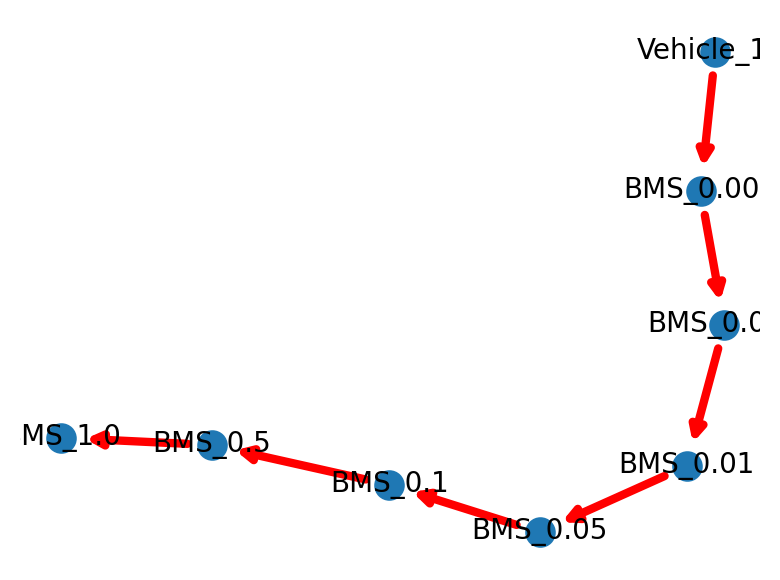

In [8]:
plt.figure(figsize=(4,3))
pos = nx.spring_layout(input_trajectories)  # positions for all nodes
nx.draw_networkx_nodes(input_trajectories, pos, node_size=100)
for u, v, data in input_trajectories.edges(data=True):
    nx.draw_networkx_edges(input_trajectories, pos, edgelist=[(u, v)], width=3, edge_color='red')
nx.draw_networkx_labels(input_trajectories, pos, font_size=10)
plt.axis("off")
plt.tight_layout()
plt.show()

# PCA Embedding

In [9]:
adata = ad.AnnData(X=adata_bms.obsm["tardis"][:,:16].copy(), obs=adata_bms.obs.copy())
embedding_object = PCAEmbedding(
    random_state=42,
    pca_params={"n_comps": 10},
    adata=adata, 
    labels=adata.obs["drug_dose_name"]
)
embedding_object.calculate()

embedding_object.get_result("pca").shape

2025-03-07 18:12:39.236 | DEBUG    | sctram.infer._base:_initialize_from_adata_without_neighbors:161 - Initializing from AnnData without precomputed neighbors.
2025-03-07 18:12:39.237 | DEBUG    | sctram.infer._base:_add_labels_to_adata:220 - Adding provided labels to AnnData object.
2025-03-07 18:12:39.238 | INFO     | sctram.infer._base:_initialize_from_adata_without_neighbors:168 - No precomputed neighbors found in AnnData.
2025-03-07 18:12:39.238 | DEBUG    | sctram.infer._base:_initialize_from_adata_without_neighbors:172 - AnnData initialized successfully from AnnData without neighbors.
2025-03-07 18:12:39.239 | INFO     | sctram.infer._base:calculate:496 - Starting PCAEmbedding embedding calculation.
2025-03-07 18:12:39.239 | INFO     | sctram.infer._base:calculate:499 - Performing embedding calculation.
2025-03-07 18:12:39.240 | INFO     | sctram.utils._loguru_scanpy_capture:emit:54 - computing PCA
2025-03-07 18:12:39.240 | INFO     | sctram.utils._loguru_scanpy_capture:emit:54 

(4094, 10)

In [10]:
embedding_object._needs_neighbors(neighbors_params={"n_neighbors": 15})

2025-03-07 18:12:39.286 | INFO     | sctram.infer._base:_needs_neighbors:514 - Computing neighbors.
2025-03-07 18:12:39.287 | INFO     | sctram.utils._loguru_scanpy_capture:emit:54 - computing neighbors
2025-03-07 18:12:39.287 | DEBUG    | sctram.utils._loguru_scanpy_capture:emit:54 - computing neighbors
2025-03-07 18:12:39.288 | INFO     | sctram.utils._loguru_scanpy_capture:emit:54 -     using data matrix X directly
2025-03-07 18:12:39.357 | DEBUG    | sctram.utils._loguru_scanpy_capture:emit:54 - computed neighbors
2025-03-07 18:12:42.034 | DEBUG    | sctram.utils._loguru_scanpy_capture:emit:54 - computed connectivities
2025-03-07 18:12:42.035 | INFO     | sctram.utils._loguru_scanpy_capture:emit:54 -     finished


In [11]:
inferred_trajectories_anndata = embedding_object.get_result("anndata")
inferred_trajectories_labels = np.array(adata_bms.obs["drug_dose_name"])

In [12]:
embedding_evaluation = EmbeddingTrajectoryEvaluation(
    method_params = dict(
        metrics = [
            # "branch_silhouette_score",
            # "sammons_stress",
            # "embedding_distance_correlation",
            # "normalized_mean_curvature",
            # "graph_based_trustworthiness",
            # "neighborhood_preservation_score",
            # "directionality_preservation",
            # "wasserstein_distance_embedding",
            # "trajectory_cardinality_validation",
            "morans_i_embedding",
            "gearys_c_embedding"
        ]
    )
)

2025-03-07 18:12:42.121 | DEBUG    | sctram.evaluate._embedding:__init__:61 - Initialized EmbeddingTrajectoryEvaluation with metrics: ['morans_i_embedding', 'gearys_c_embedding']


In [13]:
logging.getLogger().setLevel(logging.DEBUG)
try:
    embedding_evaluation.evaluate(
        given_trajectory=input_trajectories,
        inferred_trajectory=inferred_trajectories_anndata,
        labels=inferred_trajectories_labels
    )
finally:
    logging.getLogger().setLevel(logging.INFO)

2025-03-07 18:12:42.163 | INFO     | sctram.evaluate._base:evaluate:159 - Starting evaluation with EmbeddingTrajectoryEvaluation.
2025-03-07 18:12:42.164 | DEBUG    | sctram.evaluate._base:evaluate:162 - Verifying given trajectory.
2025-03-07 18:12:42.164 | DEBUG    | sctram.evaluate._base:evaluate:165 - Verifying inferred trajectory.
2025-03-07 18:12:42.165 | DEBUG    | sctram.evaluate._base:evaluate:169 - Verifying labels.
2025-03-07 18:12:42.165 | DEBUG    | sctram.evaluate._embedding:_verify_labels_data_specific:234 - Checking the consistency between the given graph and labels.
2025-03-07 18:12:42.166 | DEBUG    | sctram.evaluate._base:evaluate:199 - Performing evaluation calculation.
2025-03-07 18:12:42.169 | DEBUG    | sctram.evaluate._embedding:_calculate:77 - Calculating metric: 'morans_i_embedding'
2025-03-07 18:12:42.169 | WARNING  | sctram.evaluate._embedding:_calculate:158 - Implementation of the spatial metric 'morans_i_embedding' may be problematic.
2025-03-07 18:12:43.24

In [14]:
embedding_evaluation.get_result()

{'morans_i_embedding': 0.19478451811972095,
 'gearys_c_embedding': 0.7316652763434265}